## Projet Maladies_Cardiaques

## Application : Analyse du Risque Cardiovasculaire

Les maladies cardiovasculaires représentent l’une des principales causes de mortalité dans le monde. La prévention est un enjeu clé pour les professionnels de santé, et l’analyse des données médicales permet d’identifier les facteurs de risque afin d’anticiper les cas à haut risque.

Dans ce projet, vous travaillez en tant qu’analyste de données médicales pour une institution de santé publique.

Votre mission est d’explorer un ensemble de données cliniques anonymisées et de construire un modèle permettant d’évaluer le risque de maladie coronarienne à 10 ans (TenYearCHD) en fonction des caractéristiques des patients.

Les données contiennent des informations démographiques (âge, sexe, niveau d’éducation), des habitudes de vie (tabagisme), des antécédents médicaux (hypertension, diabète, AVC) ainsi que des mesures cliniques (cholestérol, tension artérielle, IMC, fréquence cardiaque, glucose).

L’objectif final est de fournir une analyse qui pourra être utilisée pour aider à la prise de décision médicale, en identifiant les facteurs les plus prédictifs du risque cardiovasculaire et en développant des modèles permettant d’alerter les médecins sur les patients à surveiller de près.

**Problématiques :**
- Quels sont les principaux facteurs de risque des maladies coronariennes ?
- Comment peut-on exploiter les données médicales pour améliorer la prévention ?
- Un modèle de Machine Learning peut-il prédire efficacement le risque cardiovasculaire sur 10 ans ?

**Etapes à suivre:**

1️- Exploration des Données avec Pandas : Nettoyage, analyse statistique et visualisation des tendances.

2️- Analyse des Corrélations  : Extraction d’informations pertinentes sur les facteurs de risque.

3️- Création de visualisations : Présentation des résultats sous forme de visualisations pertinentes.



- currentSmoker :	Indique si la personne est fumeuse (1 = Oui, 0 = Non)
- cigsPerDay:	Nombre de cigarettes fumées par jour (si currentSmoker = 1)
- BPMeds :	Prend des médicaments pour la pression artérielle (1 = Oui, 0 = Non)
- prevalentStroke :	Antécédents d'AVC (1 = Oui, 0 = Non)
- prevalentHyp :	Antécédents d'hypertension (1 = Oui, 0 = Non)
- diabetes :	Diabète diagnostiqué (1 = Oui, 0 = Non)
- totChol :	Cholestérol total (mg/dL)
- sysBP :	Pression artérielle systolique (mmHg)
- diaBP	: Pression artérielle diastolique (mmHg)
- BMI	:Indice de masse corporelle (IMC) = Poids (kg) / Taille² (m²)
- heartRate :	Fréquence cardiaque (battements par minute)
- glucose:	Taux de glucose dans le sang (mg/dL)

# Étape 1 : Importation des bibliothèques nécessaires

In [20]:
#!pip install ydata-profiling

In [1]:
# Importation des librairie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')                  #just ignoring all warnings

from ydata_profiling import ProfileReport   



import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

# Étape 2 : Préparation des données

In [2]:
# Importer le dataset
data = pd.read_csv("maladies_cardiaques.csv")
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [23]:
data.shape

(4238, 16)

In [24]:
### Creer un rapport contenant les stat descp du dataset avec "ydata-profiling"
profile = ProfileReport(data,explorative=True,title='maladies_cardiaques EXPLORATIVE DATA ANALYSIS')  #creating a report

In [ ]:
profile.to_file("maladies_cardiaques.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:00<00:00, 30.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# La description de chaque colonne 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
# List des colonnes
data.columns.tolist()

['male',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [5]:
data.describe(exclude = "object")

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
# Identification des valeurs manquantes

# Somme des valeurs manquantes
valeur_manq = data.isnull().sum()

# Pourcentage des valeurs manquantes
pourc_valeur_manq = (valeur_manq / len(data)) * 100

# Tableau des valeurs manquantes par variables
table_valeur_manq = pd.DataFrame({ "Valeur_manquante": valeur_manq, "Porcentage": pourc_valeur_manq})
print(table_valeur_manq)

                 Valeur_manquante  Porcentage
male                            0    0.000000
age                             0    0.000000
education                     105    2.477584
currentSmoker                   0    0.000000
cigsPerDay                     29    0.684285
BPMeds                         53    1.250590
prevalentStroke                 0    0.000000
prevalentHyp                    0    0.000000
diabetes                        0    0.000000
totChol                        50    1.179802
sysBP                           0    0.000000
diaBP                           0    0.000000
BMI                            19    0.448325
heartRate                       1    0.023596
glucose                       388    9.155262
TenYearCHD                      0    0.000000


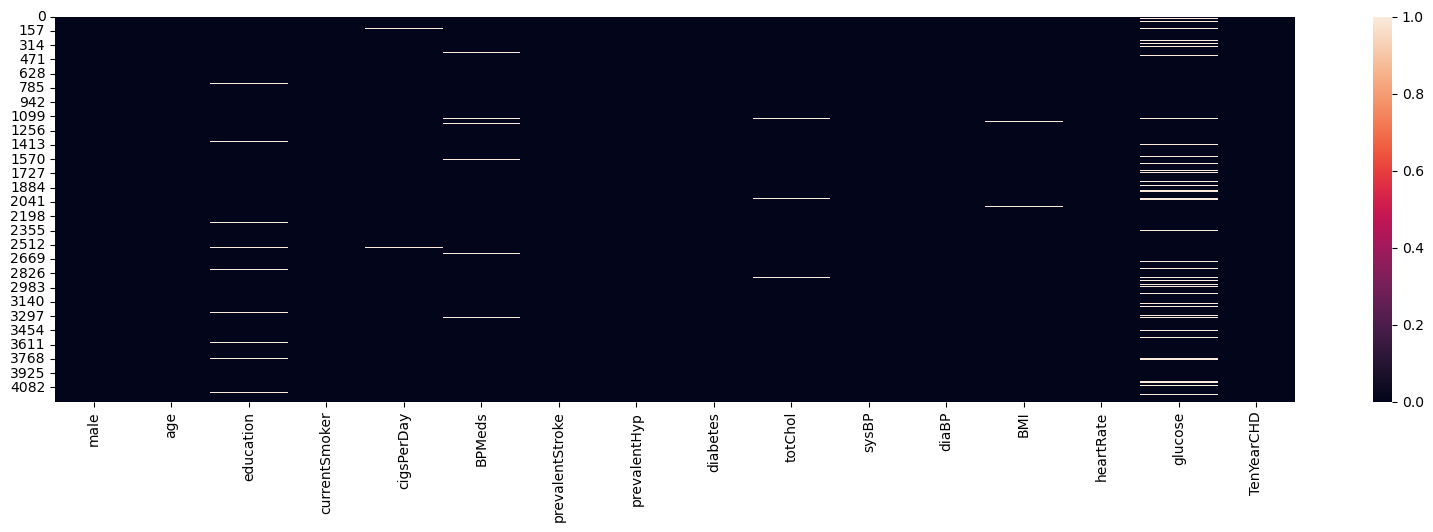

In [7]:
plt.figure(figsize=(20, 5))
sns.heatmap(data.isnull(), cbar=True)
plt.show()

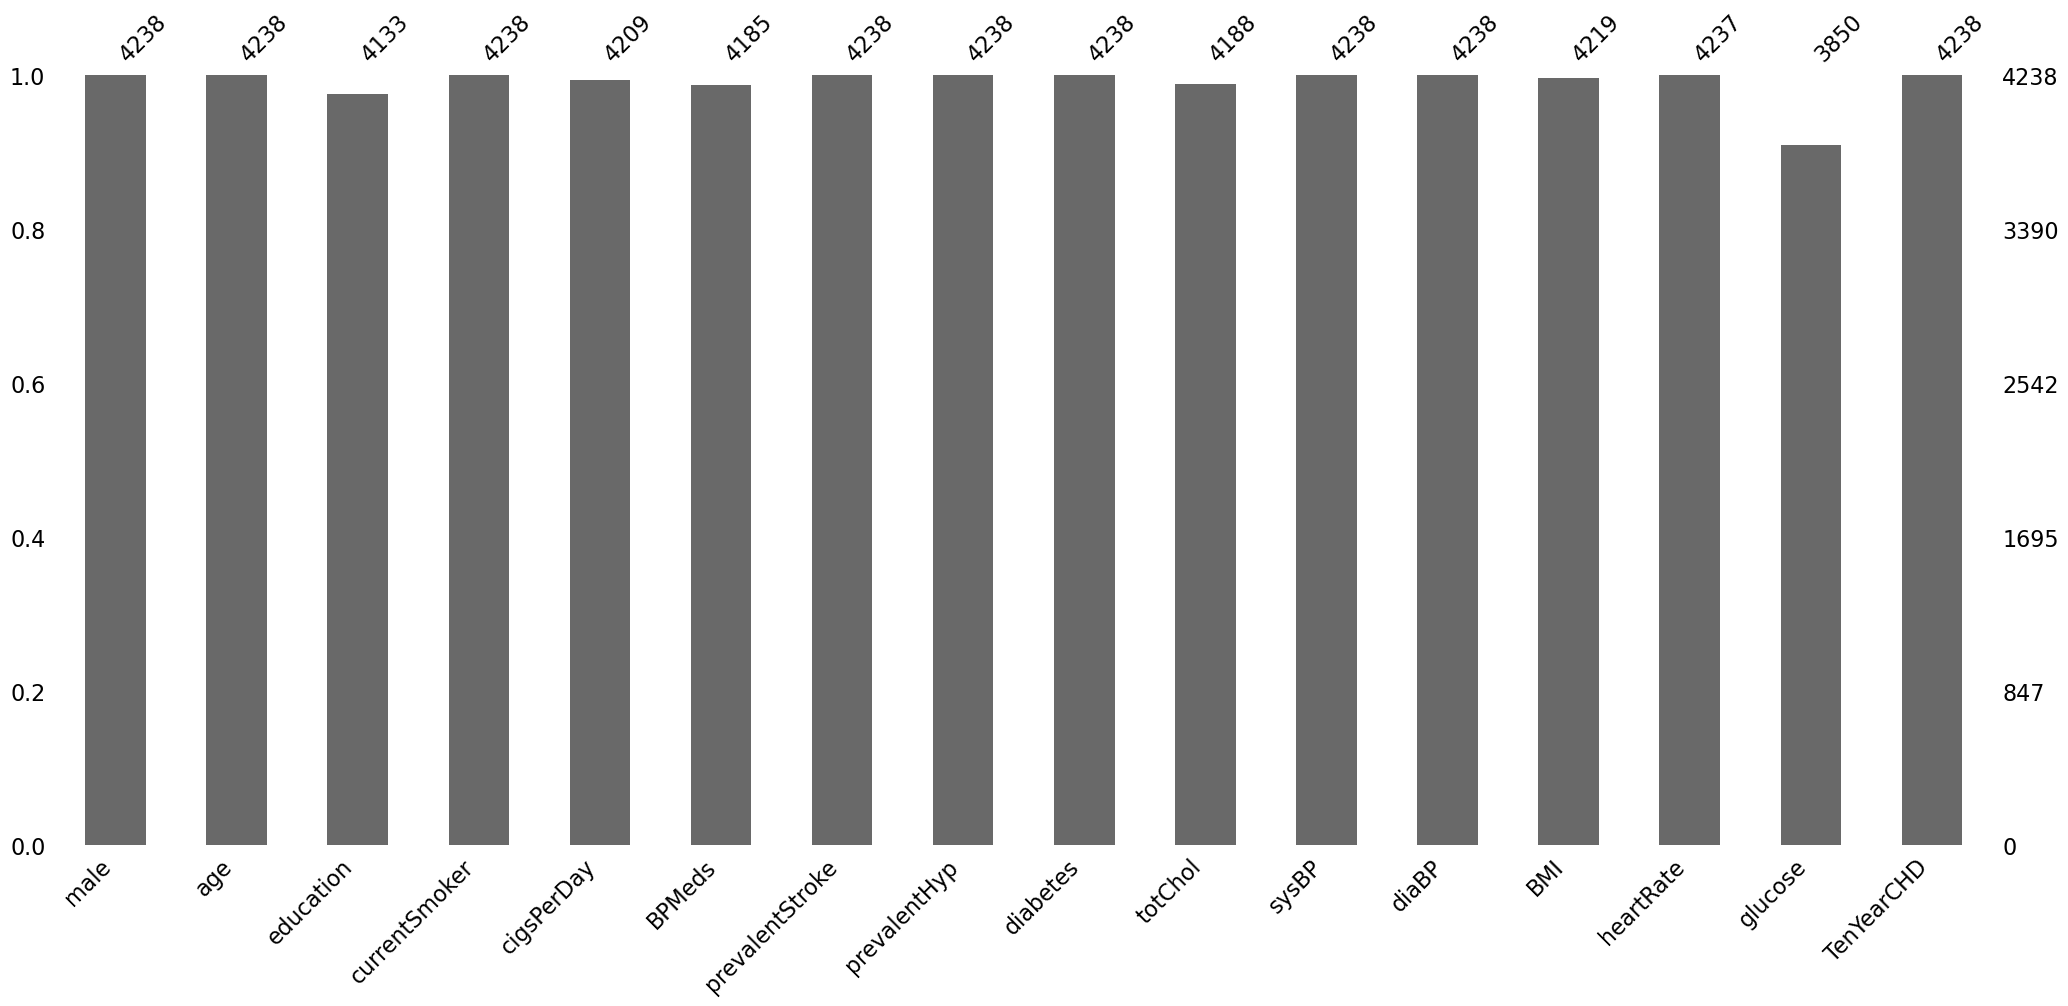

In [8]:
import missingno as msno
# Barplot des valeurs manquantes
msno.bar(data)
plt.show()

<Axes: ylabel='Density'>

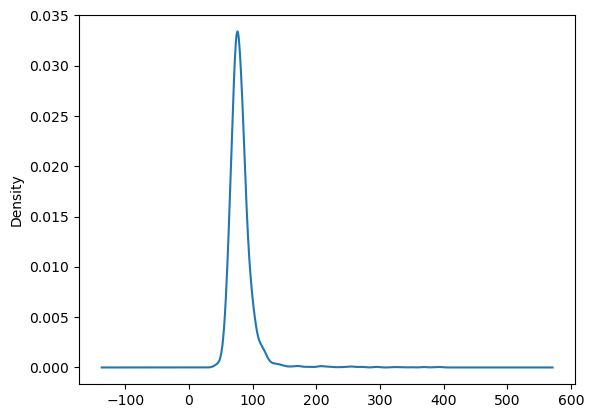

In [9]:
data["glucose"].plot(kind = "density")

In [10]:
# Remplacer le valeur manquante de la var glucose par la moyenne
mean = data['glucose'].mean()
data['glucose']=data['glucose'].fillna(mean)

In [11]:
valeur_manq = data.isnull().sum()
valeur_manq

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose              0
TenYearCHD           0
dtype: int64

In [22]:
# Supprimer les NAN
data.dropna(axis = 0, inplace = True)

In [23]:
data.shape

(3987, 16)

# Étape 3 : Analyse exploratoire des données 

#### La distribution des valeurs dans la TenYearCHD

In [24]:
data["TenYearCHD"].value_counts()

TenYearCHD
0    3392
1     595
Name: count, dtype: int64

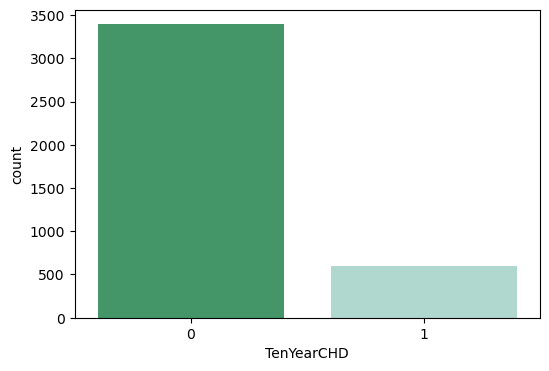

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="TenYearCHD", data=data, palette="BuGn_r")
plt.show()

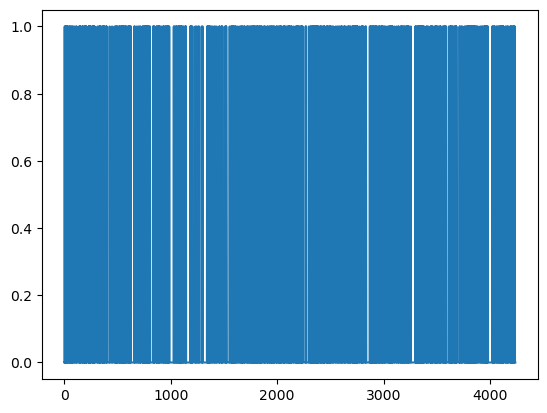

In [26]:
comptage = data["TenYearCHD"].plot()
plt.show(comptage)

#### Corrélation entre les différente var

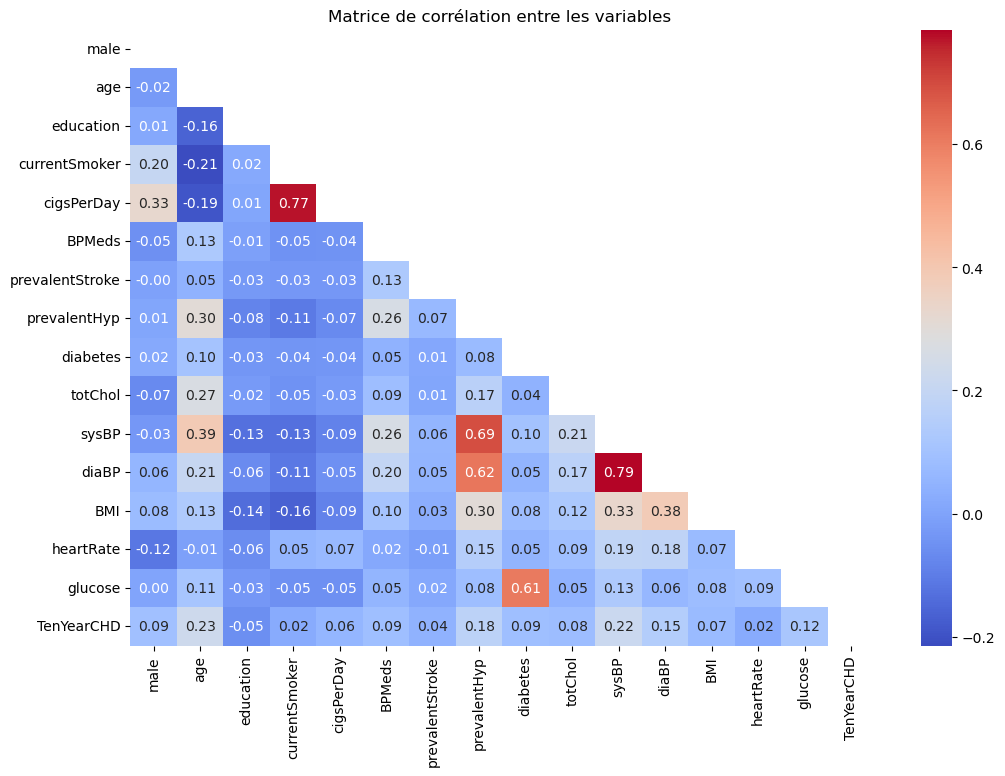

In [27]:
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation entre les variables ")
plt.show()

In [16]:
# Corr de TenYearCHD et les autres variables 
data.corr(numeric_only=True)["TenYearCHD"]

male               0.088428
age                0.225256
education         -0.054059
currentSmoker      0.019456
cigsPerDay         0.057884
BPMeds             0.087489
prevalentStroke    0.061810
prevalentHyp       0.177603
diabetes           0.097317
totChol            0.082184
sysBP              0.216429
diaBP              0.145299
BMI                0.075192
heartRate          0.022913
glucose            0.120406
TenYearCHD         1.000000
Name: TenYearCHD, dtype: float64

#### Visualiser les relations entre toutes les paires de variables dans un dataset.

<Figure size 600x200 with 0 Axes>

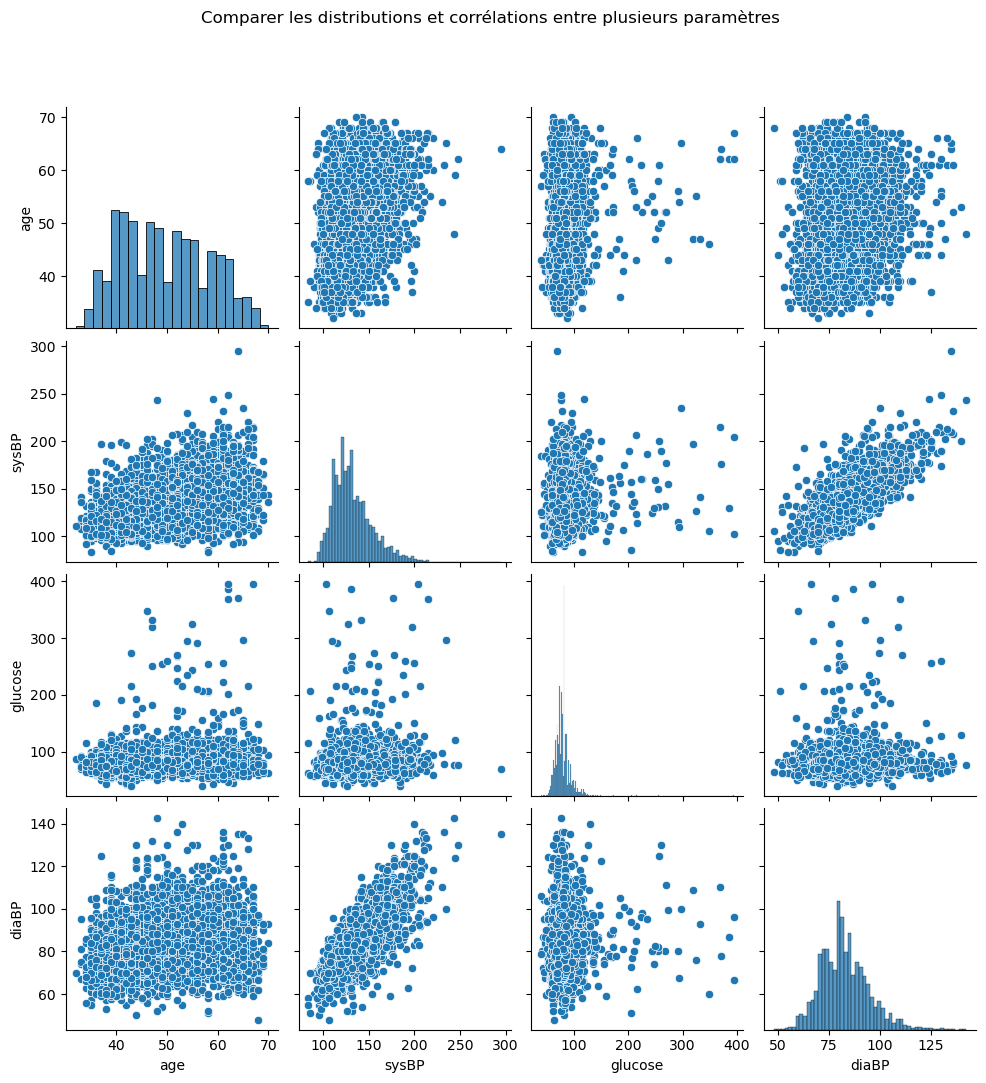

In [17]:
var = data[["age","sysBP","glucose", "diaBP"]]
plt.figure(figsize=(6,2))
sns.pairplot(data, vars= var)
plt.suptitle("Comparer les distributions et corrélations entre plusieurs paramètres ",y=1.08)
plt.show()

# Étape 4 : Division de l'ensemble de données en ensembles de test et d'apprentissage

- X = preprocessing.StandardScaler().fit(X).transform(X): Cela met à l'échelle les fonctionnalités Xpour avoir une moyenne de 0 et un écart type de 1 à -l'aide de StandardScaler.
La mise à l’échelle est importante pour de nombreux modèles d’apprentissage automatique, en particulier lorsque les fonctionnalités ont des unités ou des grandeurs différentes.
- Ensemble d'entraînement (70 % des données X_trainet y_train)
- Ensemble de tests (30 % des données, X_testet y_test)
- random_state=4assure que la division est reproductible.

In [28]:
X = np.asarray(data[['age', 'male', 'cigsPerDay', 
                           'totChol', 'sysBP', 'glucose']])
y = np.asarray(data['TenYearCHD'])

X = preprocessing.StandardScaler().fit(X).transform(X)

X_train, X_test, y_train, y_test = train_test_split( 
        X, y, test_size = 0.3, random_state = 4)

print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (2790, 6) (2790,)
Test set: (1197, 6) (1197,)


# Étape 5 : Ajustement du modèle de régression logistique pour la prédiction des maladies cardiaques

- logreg = LogisticRegression():Cela crée une instance du modèle LogisticRegression.
- logreg.fit(X_train, y_train):Cela entraîne le modèle de régression logistique à l'aide des données d'entraînement ( X_trainpour les fonctionnalités et y_trainpour la cible).
- y_pred = logreg.predict(X_test): Ceci utilise le modèle de régression logistique formé pour faire des prédictions sur l'ensemble de test ( X_test). Les valeurs prédites sont stockées dans y_pred.

In [30]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

# Étape 6 : Évaluation du modèle de régression logistique

In [33]:
print("La précision de notre modèle est: ", accuracy_score(y_test, y_pred))

La précision de notre modèle est:  0.8613199665831245
